In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ModuleNotFoundError: No module named 'pandas'

In [3]:
df = pd.read_csv("C:\\Users\\DIVISAVEE\\OneDrive\\Desktop\\Savee\\HeartAI\\data\\processed\\heart_cleaned.csv")

In [4]:
df.shape

(302, 14)

In [5]:
X = df.drop('target', axis=1)
y = df['target']

In [6]:
print(X.shape)
print(y.shape)

(302, 13)
(302,)


In [7]:
X.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print(X_train.shape)
print(X_test.shape)

(241, 13)
(61, 13)


In [10]:
y_train.value_counts()

target
1    131
0    110
Name: count, dtype: int64

In [11]:
y_test.value_counts()

target
1    33
0    28
Name: count, dtype: int64

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
X_train_scaled.shape

(241, 13)

In [14]:
import joblib

joblib.dump(
    scaler,
    "C:/Users/DIVISAVEE/OneDrive/Desktop/Savee/HeartAI/models/scaler.pkl"
)

['C:/Users/DIVISAVEE/OneDrive/Desktop/Savee/HeartAI/models/scaler.pkl']

In [16]:
pd.DataFrame(X_train).to_csv(
    "C:/Users/DIVISAVEE/OneDrive/Desktop/Savee/HeartAI/data/processed/X_train.csv",
    index=False
)

pd.DataFrame(X_test).to_csv(
    "C:/Users/DIVISAVEE/OneDrive/Desktop/Savee/HeartAI/data/processed/X_test.csv",
    index=False
)

In [17]:
X.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')

In [19]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


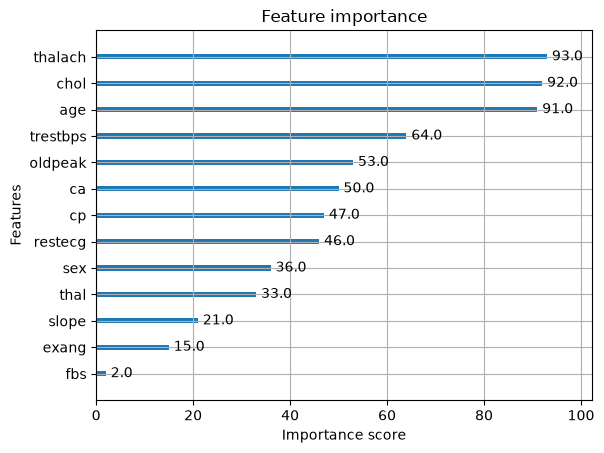

In [20]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()

In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train, y_train)

for feature, importance in zip(
        X.columns,
        xgb.feature_importances_
):
    print(feature, importance)

age 0.046665516
sex 0.061322488
cp 0.30401465
trestbps 0.025849309
chol 0.031392757
fbs 0.012623804
restecg 0.038157735
thalach 0.039223693
exang 0.11017623
oldpeak 0.052831907
slope 0.03808285
ca 0.10459155
thal 0.1350675


## XGBoost Feature Importance

The XGBoost model identified Chest Pain (`cp`) as the most influential feature, contributing approximately 30% of the model's predictive power. Other significant predictors included Thalassemia (`thal`), Exercise-Induced Angina (`exang`), and the Number of Major Vessels (`ca`).

Interestingly, Cholesterol and Fasting Blood Sugar exhibited relatively low importance, suggesting that heart disease prediction in this dataset is more strongly influenced by clinical and exercise-related measurements.